# 4 — Valutazione quantitativa

100 MRI sintetiche (modello finale: timestep **uniformi** + **autoguidance** w=2.0) confrontate con le reali, su **test set** (102 hold-out) e **intero dataset** (1007):

- **FID 2.5D** (3 piani XY/YZ/ZX): realismo distribuzionale. Piu' basso = meglio.
- **MMD**: distanza distribuzionale complementare. Piu' basso = meglio.
- **MS-SSIM** intra-set: diversita' (controllo mode collapse). *Interpretabile solo a campioni allineati.*
- **QC geometrico** (`check_degenerate_samples.py`): frazione di campioni fuori posizione. Cattura l'artefatto che FID e MS-SSIM non vedono.

Piu' i due grafici della selezione dei checkpoint: la **curva FID-vs-epoca** (senza guida) e il **confronto con/senza autoguidance** sui migliori.

In [1]:
import os, sys, json, glob
ROOT=os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

def show_ortho(vol, title=None, ax_row=None, cmap="gray"):
    """Mostra le 3 viste ortogonali (centrali) di un volume 3D."""
    if hasattr(vol, "numpy"):
        vol=vol.numpy()
    vol=np.asarray(vol).squeeze()
    x, y, z=[s // 2 for s in vol.shape]
    views=[(np.rot90(vol[x, :, :]), "Sagittale"),
             (np.rot90(vol[:, y, :]), "Coronale"),
             (np.rot90(vol[:, :, z]), "Assiale")]
    axes=ax_row if ax_row is not None else plt.subplots(1, 3, figsize=(12, 4))[1]
    for a, (img, name) in zip(axes, views):
        a.imshow(img, cmap=cmap); a.set_title(name); a.axis("off")
    if title and ax_row is None:
        plt.suptitle(title); plt.tight_layout()
    return axes


## Tabella riassuntiva delle metriche

In [2]:
with open("outputs/metrics/eval_test_v4.json") as f: ev_test=json.load(f)
with open("outputs/metrics/eval_all_v4.json") as f: ev_all=json.load(f)

rows = [
    ("FID XY",        "fid_xy"),
    ("FID YZ",        "fid_yz"),
    ("FID ZX",        "fid_zx"),
    ("FID medio",     "fid_avg"),
    ("MMD",           "mmd"),
    ("MS-SSIM sint",  "msssim_synth"),
    ("MS-SSIM reali", "msssim_real"),
]
h_metric, h_test, h_all="Metrica", "test (102)", "all (1007)"
print(f"{h_metric:<15}{h_test:>14}{h_all:>14}")
print("-"*43)
for name, key in rows:
    print(f"{name:<15}{ev_test[key]:>14.4f}{ev_all[key]:>14.4f}")

Metrica            test (102)    all (1007)
-------------------------------------------
FID XY                27.0231       26.3247
FID YZ                30.9127       30.2112
FID ZX                23.6077       23.1788
FID medio             27.1812       26.5716
MMD                    0.0089        0.0089
MS-SSIM sint           0.9472        0.9472
MS-SSIM reali          0.9357        0.9355


## Selezione dei checkpoint: curva FID-vs-epoca

Selezione grezza (senza autoguidance) su tutti i checkpoint periodici dell'LDM.

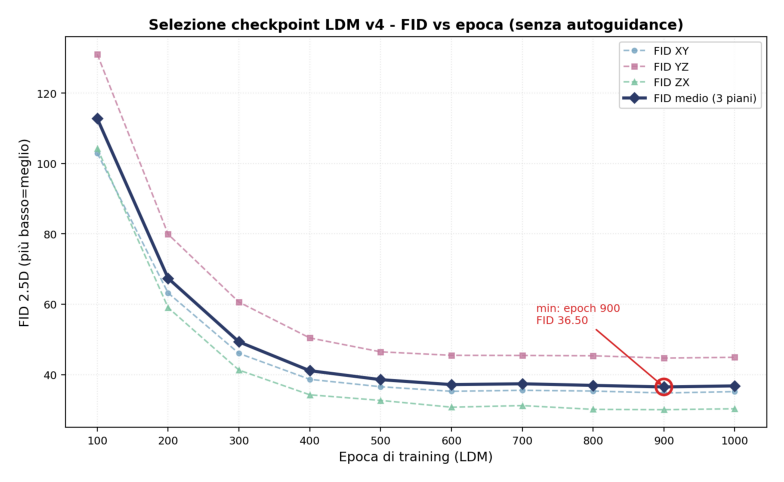

In [3]:
fig_path="outputs/metrics/fid_vs_epoch_v4.png"
if os.path.exists(fig_path):
    fig, ax=plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(fig_path)); ax.axis("off"); plt.show()
else:
    from src.evaluation.plot_fid_curve import plot_fid_curve
    plot_fid_curve("outputs/checkpoint_selection_v4/fid_by_checkpoint_v4.json",
                   save_path=fig_path)
    plt.show()

## Effetto dell'autoguidance sui checkpoint migliori

Raffinamento dei top-3 della curva precedente, rivalutati **con** autoguidance.

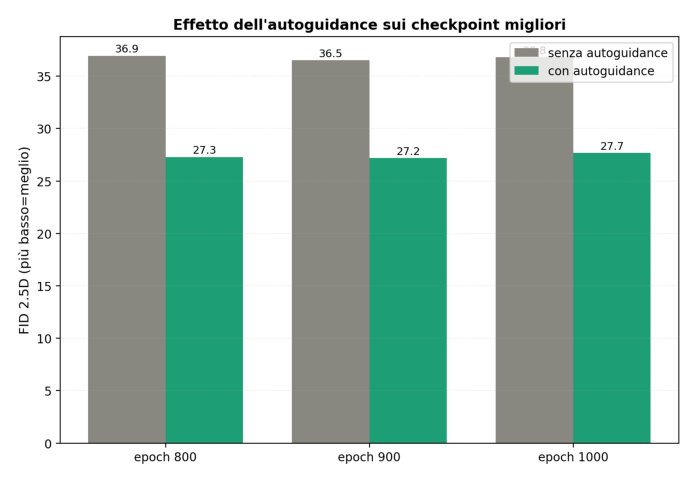

In [4]:
fig_path="outputs/metrics/fid_autoguidance_top_v4.png"
if os.path.exists(fig_path):
    fig, ax=plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(fig_path)); ax.axis("off"); plt.show()
else:
    print(f"{fig_path} non trovato (eseguire checkpoint_selection.py con --refine_top)")

## Lettura dei risultati

**Realismo.** FID medio **27.18** su test (102) e **26.57** su all (1007): stima stabile al variare del riferimento reale. Rispetto al baseline (FID ~39) il miglioramento e' del **~30%**, senza modificare il VAE, senza dati aggiuntivi, senza EMA.

**Concordanza fra metriche.** MMD **0.0089** su entrambi i riferimenti (dimezzato rispetto alla variante logit-normale, 0.019): la distanza distribuzionale conferma il FID e premia il modello uniforme, piu' vicino ai reali a livello di struttura globale.

**Diversita'.** MS-SSIM sintetiche **0.9472** contro reali **0.9356**: i campioni sono lievemente piu' simili tra loro dei reali — coerente con la texture piu' morbida — ma **nessun mode collapse**. NB: questa metrica e' interpretabile solo ora, a campioni allineati; nella variante logit-normale valeva 0.8946, un valore depresso *artificialmente* dalle traslazioni (una traslazione globale abbassa la MS-SSIM a prescindere dalla diversita' anatomica).

**Uniformita' fra piani.** FID XY/YZ/ZX = 27.02/30.91/23.61 (test). Il piano sagittale resta il piu' alto, coerente con la variabilita' anatomica inter-soggetto.

**L'artefatto di posizionamento (risultato metodologico centrale).** Una variante con timestep **logit-normali** dava un FID migliore (21.8) ma generava ~20% di volumi con **traslazione globale quantizzata** a ±32 voxel immagine (= 1 voxel al collo di bottiglia della UNet); un campione era tagliato dal bordo. Ne' il **FID** (che aggrega slice sull'intero volume: una traslazione lascia il set di slice quasi invariato) ne' la **MS-SSIM** rilevano il difetto: e' stato individuato per **ispezione visiva** e quantificato con una metrica geometrica dedicata (centroide/estensione/frazione di tessuto vs distribuzione dei reali). Un esperimento controllato — unica variabile il campionamento dei timestep, stessi latenti, stessi seed — ha mostrato che il passaggio a timestep **uniformi** elimina l'artefatto (**0%** di traslati vs 40% senza guida, 20% con guida per il logit-normale). Il modello finale adotta quindi i timestep uniformi: perde qualche punto di FID ma vince su MMD, MS-SSIM e correttezza geometrica.

**Sulla selezione dei checkpoint.** Con timestep uniformi la curva FID-vs-epoca e' **regolare e converge** a un plateau (~37 senza guida, epoch 600-1000), a differenza della curva logit-normale che oscillava con due minimi e un massimo anomalo — un ulteriore indizio della maggiore stabilita' del training uniforme. Il raffinamento con autoguidance ha **ribaltato la classifica** (senza guida epoch 900/1000 quasi pari; con guida vince epoch 900, FID 27.2), confermando la necessita' del raffinamento dei top-K.